GREY WOLF OPTIMIZATION (GWO)
Number of wolves : 30
Iterations       : 50
Runs             : 30
Search range     : x,y in [-5, 5]
Random seed      : 42

Initial positions for manual calculation:
Wolf 1: x=-4.00, y=4.00
Wolf 2: x=-2.00, y=3.00
Wolf 3: x=0.00, y=2.00
Wolf 4: x=2.00, y=-1.00
Wolf 5: x=4.00, y=3.00

Manual calculation files created.

Running Rosenbrock...
Running Rastrigin...

ROSENBROCK FUNCTION
Best Fitness  : 0.0000094761
Mean Fitness  : 0.0095097811
Worst Fitness : 0.0488491303
Std Deviation : 0.0118663641
Avg Runtime   : 0.068275 seconds

RASTRIGIN FUNCTION
Best Fitness  : 0.0000000000
Mean Fitness  : 0.1327939936
Worst Fitness : 0.9968412090
Std Deviation : 0.3385596728
Avg Runtime   : 0.065664 seconds


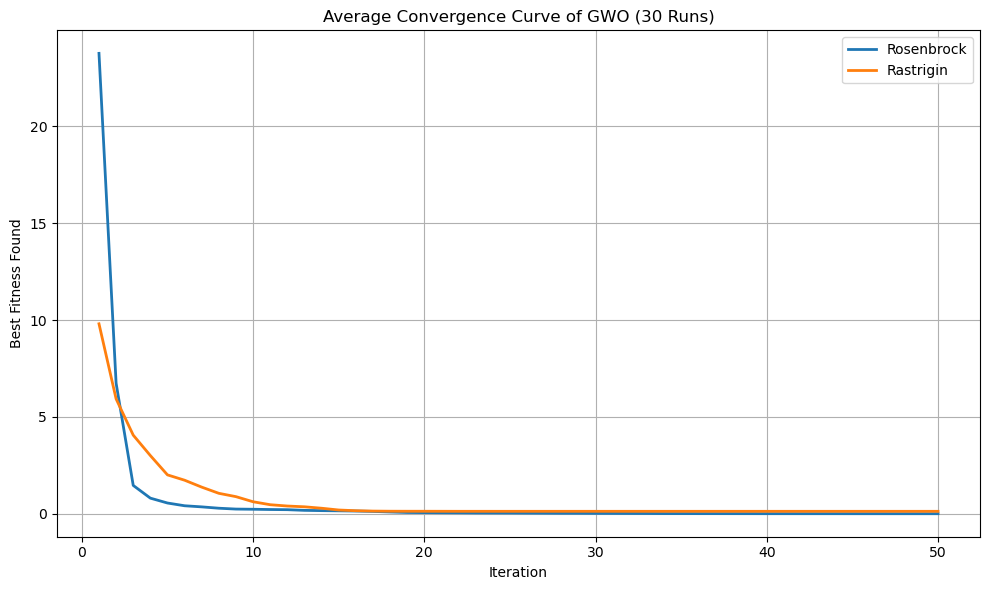


REAL-WORLD EXAMPLE: IoT SENSOR PLACEMENT
Optimal sensor x : 0.281378
Optimal sensor y : 1.688276
Best fitness     : 20.03402036
Runtime          : 0.092150 seconds


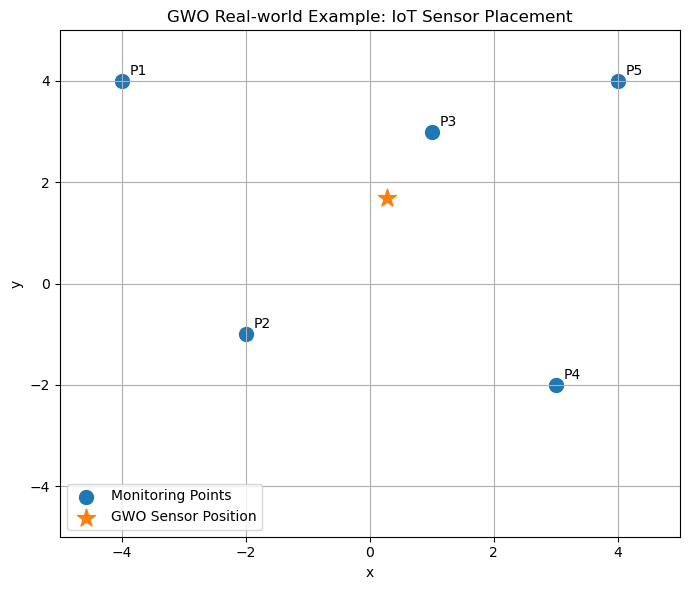

IndexError: index 3 is out of bounds for axis 0 with size 3

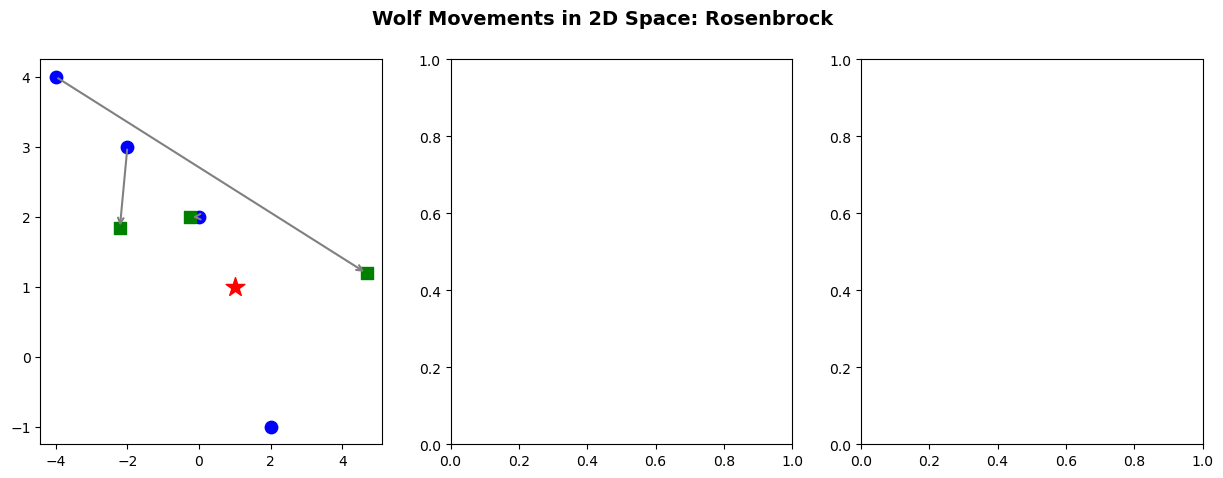

In [ ]:
"""
Grey Wolf Optimization (GWO) - Assignment 1
Based on the mathematical model/pseudocode in the supplied GWO chapter.

Requirements covered:
1) GWO
2) Rosenbrock + Rastrigin
3) Manual calculation for 2 iterations
4) >=20 iterations (50 by default)
5) Best / Mean / Worst / Std / Average Runtime
6) Average convergence curves over 30 runs
7) Real-world example: 2D IoT sensor placement optimization
8) Comments identify the GWO equation being used.

No scipy.optimize / optimization library is used.
Only NumPy, Matplotlib and Python standard library are required.
"""

import os
import time
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 0) EXPERIMENT SETTINGS
# ============================================================
SEED = 42

DIM = 2
NUM_WOLVES = 30
MAX_ITER = 50
NUM_RUNS = 30

# Search range for x,y.
# The exact optimum of both benchmark functions is inside this range.
LOWER_BOUND = np.array([-5.0, -5.0])
UPPER_BOUND = np.array([5.0, 5.0])

OUTPUT_DIR = "GWO_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 1) OBJECTIVE / BENCHMARK FUNCTIONS
# ============================================================
def rosenbrock(pos):
    """
    Rosenbrock function:
        f(x,y) = (1-x)^2 + 100(y-x^2)^2

    Global optimum:
        (x,y) = (1,1)
        f(x,y) = 0
    """
    x, y = pos[0], pos[1]
    return (1.0 - x)**2 + 100.0 * (y - x**2)**2


def rastrigin(pos):
    """
    Rastrigin function:
        f(x,y) = 20 + x^2 + y^2
                 - 10[cos(2*pi*x) + cos(2*pi*y)]

    Global optimum:
        (x,y) = (0,0)
        f(x,y) = 0
    """
    x, y = pos[0], pos[1]
    return (
        20.0
        + x**2
        + y**2
        - 10.0 * (
            np.cos(2.0 * np.pi * x)
            + np.cos(2.0 * np.pi * y)
        )
    )


# ============================================================
# 2) HELPER FUNCTIONS
# ============================================================
def clip_position(position):
    """Keep every wolf inside the allowed search space."""
    return np.clip(position, LOWER_BOUND, UPPER_BOUND)


def initialize_population(rng, num_wolves=NUM_WOLVES):
    """
    Initial solution:
    The supplied chapter states that GWO starts by creating
    a random population of grey wolves (candidate solutions).

    Therefore, the main experiment uses random x,y in [-5,5].
    """
    return rng.uniform(
        LOWER_BOUND,
        UPPER_BOUND,
        size=(num_wolves, DIM)
    )


def rank_leaders(positions, fitness):
    """
    Rank the current population.

    According to the supplied chapter:
      - Alpha = best solution
      - Beta  = second-best solution
      - Delta = third-best solution
      - Other wolves follow them.

    Source: GWO social hierarchy.
    """
    order = np.argsort(fitness)

    alpha_idx = order[0]
    beta_idx = order[1]
    delta_idx = order[2]

    alpha_pos = positions[alpha_idx].copy()
    beta_pos = positions[beta_idx].copy()
    delta_pos = positions[delta_idx].copy()

    alpha_score = fitness[alpha_idx]
    beta_score = fitness[beta_idx]
    delta_score = fitness[delta_idx]

    return (
        alpha_pos, alpha_score,
        beta_pos, beta_score,
        delta_pos, delta_score
    )


# ============================================================
# 3) ONE GWO RUN
# ============================================================
def gwo_run(
    objective_function,
    rng,
    initial_positions=None,
    num_wolves=NUM_WOLVES,
    max_iter=MAX_ITER,
    record_manual=False
):
    """
    One complete GWO run.

    Main GWO equations used:

    Equation (9.1):
        D = | C * Xp - X |

    Equation (9.2):
        X(t+1) = Xp - A * D

    Equation (9.3):
        A = 2*a*r1 - a

    Equation (9.4):
        C = 2*r2

    Equations (9.5)-(9.6):
        D_alpha = |C1*X_alpha - X|
        D_beta  = |C2*X_beta  - X|
        D_delta = |C3*X_delta - X|

        X1 = X_alpha - A1*D_alpha
        X2 = X_beta  - A2*D_beta
        X3 = X_delta - A3*D_delta

        X(t+1) = (X1 + X2 + X3) / 3

    The parameter a decreases linearly from 2 to 0.
    """

    if initial_positions is None:
        positions = initialize_population(rng, num_wolves)
    else:
        positions = np.array(initial_positions, dtype=float, copy=True)

    convergence = np.zeros(max_iter)

    global_best_score = float("inf")
    global_best_pos = None

    manual_records = []

    for iteration in range(max_iter):

        # ----------------------------------------------------
        # Fitness evaluation + Alpha/Beta/Delta
        # ----------------------------------------------------
        fitness = np.array(
            [objective_function(p) for p in positions]
        )

        (
            alpha_pos, alpha_score,
            beta_pos, beta_score,
            delta_pos, delta_score
        ) = rank_leaders(positions, fitness)

        # Keep the best solution found over the whole run.
        if alpha_score < global_best_score:
            global_best_score = alpha_score
            global_best_pos = alpha_pos.copy()

        # ----------------------------------------------------
        # Equation for a:
        # a decreases linearly from 2 -> 0
        # ----------------------------------------------------
        if max_iter == 1:
            a = 0.0
        else:
            a = 2.0 - (2.0 * iteration / (max_iter - 1))

        old_positions = positions.copy()

        # ----------------------------------------------------
        # Update every wolf
        # ----------------------------------------------------
        for i in range(num_wolves):

            x = old_positions[i].copy()
            new_candidates = []

            # =================================================
            # Alpha contribution
            # =================================================
            r1_alpha = rng.random(DIM)
            r2_alpha = rng.random(DIM)

            # Equation (9.3):
            # A1 = 2*a*r1 - a
            A1 = 2.0 * a * r1_alpha - a

            # Equation (9.4):
            # C1 = 2*r2
            C1 = 2.0 * r2_alpha

            # Equation (9.5):
            # D_alpha = |C1*X_alpha - X|
            D_alpha = np.abs(C1 * alpha_pos - x)

            # Equation (9.6):
            # X1 = X_alpha - A1*D_alpha
            X1 = alpha_pos - A1 * D_alpha

            # =================================================
            # Beta contribution
            # =================================================
            r1_beta = rng.random(DIM)
            r2_beta = rng.random(DIM)

            # Equation (9.3):
            # A2 = 2*a*r1 - a
            A2 = 2.0 * a * r1_beta - a

            # Equation (9.4):
            # C2 = 2*r2
            C2 = 2.0 * r2_beta

            # Equation (9.5):
            # D_beta = |C2*X_beta - X|
            D_beta = np.abs(C2 * beta_pos - x)

            # Equation (9.6):
            # X2 = X_beta - A2*D_beta
            X2 = beta_pos - A2 * D_beta

            # =================================================
            # Delta contribution
            # =================================================
            r1_delta = rng.random(DIM)
            r2_delta = rng.random(DIM)

            # Equation (9.3):
            # A3 = 2*a*r1 - a
            A3 = 2.0 * a * r1_delta - a

            # Equation (9.4):
            # C3 = 2*r2
            C3 = 2.0 * r2_delta

            # Equation (9.5):
            # D_delta = |C3*X_delta - X|
            D_delta = np.abs(C3 * delta_pos - x)

            # Equation (9.6):
            # X3 = X_delta - A3*D_delta
            X3 = delta_pos - A3 * D_delta

            # Equation (9.6):
            # New position = average of X1, X2, X3
            new_position = (X1 + X2 + X3) / 3.0

            # Boundary handling (not part of the GWO equation itself).
            positions[i] = clip_position(new_position)

            # Save details only for the first 2 iterations
            # when manual calculation is requested.
            if record_manual and iteration < 2 and i < 3:
                manual_records.append({
                    "iteration": iteration + 1,
                    "wolf": i + 1,
                    "old_position": x.copy(),
                    "fitness": float(fitness[i]),
                    "a": float(a),
                    "A1": A1.copy(),
                    "C1": C1.copy(),
                    "D_alpha": D_alpha.copy(),
                    "X1": X1.copy(),
                    "A2": A2.copy(),
                    "C2": C2.copy(),
                    "D_beta": D_beta.copy(),
                    "X2": X2.copy(),
                    "A3": A3.copy(),
                    "C3": C3.copy(),
                    "D_delta": D_delta.copy(),
                    "X3": X3.copy(),
                    "new_position": positions[i].copy(),
                })

        # Convergence curve = best fitness found so far.
        convergence[iteration] = global_best_score

    return global_best_score, global_best_pos, convergence, manual_records


# ============================================================
# 4) MANUAL CALCULATION: EXACTLY 2 ITERATIONS
# ============================================================
def create_manual_initial_positions():
    """
    Explicit initial x,y values for the presentation/manual example.

    These values are intentionally spread around the search space
    so Alpha/Beta/Delta are visibly different.

    The main 30-run experiment still uses random initialization,
    as described in the supplied GWO chapter.
    """
    return np.array([
        [-4.0,  4.0],
        [-2.0,  3.0],
        [ 0.0,  2.0],
        [ 2.0, -1.0],
        [ 4.0,  3.0],
    ], dtype=float)


def write_manual_calculation(
    filename,
    objective_name,
    objective_function,
    initial_positions
):
    """
    Generate a Markdown file containing the numerical calculations
    for 2 GWO iterations.
    """

    rng = np.random.default_rng(SEED)

    _, _, _, records = gwo_run(
        objective_function=objective_function,
        rng=rng,
        initial_positions=initial_positions,
        num_wolves=len(initial_positions),
        max_iter=2,
        record_manual=True
    )

    with open(filename, "w", encoding="utf-8") as f:

        f.write("# GWO Manual Calculation - 2 Iterations\n\n")
        f.write(f"## Function: {objective_name}\n\n")

        f.write("### Initial positions\n\n")
        f.write("| Wolf | x | y |\n")
        f.write("|---:|---:|---:|\n")

        for i, p in enumerate(initial_positions, start=1):
            f.write(f"| {i} | {p[0]:.4f} | {p[1]:.4f} |\n")

        f.write("\n---\n\n")

        f.write("## Equations used\n\n")
        f.write("**Eq. (9.1)**  D = |C × Xp - X|\n\n")
        f.write("**Eq. (9.2)**  X(t+1) = Xp - A × D\n\n")
        f.write("**Eq. (9.3)**  A = 2 × a × r1 - a\n\n")
        f.write("**Eq. (9.4)**  C = 2 × r2\n\n")
        f.write("**Eq. (9.6)**  X(t+1) = (X1 + X2 + X3) / 3\n\n")

        for rec in records:

            f.write(
                f"## Iteration {rec['iteration']} - Wolf {rec['wolf']}\n\n"
            )

            p = rec["old_position"]

            f.write(
                f"Old position = "
                f"[{p[0]:.4f}, {p[1]:.4f}]\n\n"
            )

            f.write(f"Fitness = {rec['fitness']:.8f}\n\n")
            f.write(f"**a = {rec['a']:.8f}**\n\n")

            for axis, k in zip(["x", "y"], [0, 1]):

                f.write(f"### Axis {axis}\n\n")

                f.write(
                    f"Alpha: A1 = {rec['A1'][k]:.6f}, "
                    f"C1 = {rec['C1'][k]:.6f}, "
                    f"D_alpha = {rec['D_alpha'][k]:.6f}, "
                    f"X1 = {rec['X1'][k]:.6f}\n\n"
                )

                f.write(
                    f"Beta: A2 = {rec['A2'][k]:.6f}, "
                    f"C2 = {rec['C2'][k]:.6f}, "
                    f"D_beta = {rec['D_beta'][k]:.6f}, "
                    f"X2 = {rec['X2'][k]:.6f}\n\n"
                )

                f.write(
                    f"Delta: A3 = {rec['A3'][k]:.6f}, "
                    f"C3 = {rec['C3'][k]:.6f}, "
                    f"D_delta = {rec['D_delta'][k]:.6f}, "
                    f"X3 = {rec['X3'][k]:.6f}\n\n"
                )

                f.write(
                    "New position = (X1 + X2 + X3) / 3 "
                    f"= {rec['new_position'][k]:.6f}\n\n"
                )

            f.write(
                f"**New position = "
                f"[{rec['new_position'][0]:.6f}, "
                f"{rec['new_position'][1]:.6f}]**\n\n"
            )

            f.write("---\n\n")


# ============================================================
# 5) MULTI-RUN EVALUATION
# ============================================================
def evaluate_gwo(objective_function):
    """
    Run GWO 30 times and calculate:
        Best
        Mean
        Worst
        Standard Deviation
        Average Runtime
        Average Convergence Curve
    """

    best_scores = []
    runtimes = []
    curves = []

    for run in range(NUM_RUNS):

        # Different reproducible random stream for each run.
        rng = np.random.default_rng(SEED + run)

        start = time.perf_counter()

        best_score, best_position, curve, _ = gwo_run(
            objective_function=objective_function,
            rng=rng,
            num_wolves=NUM_WOLVES,
            max_iter=MAX_ITER
        )

        runtime = time.perf_counter() - start

        best_scores.append(best_score)
        runtimes.append(runtime)
        curves.append(curve)

    best_scores = np.array(best_scores)
    curves = np.array(curves)

    return {
        "Best": np.min(best_scores),
        "Mean": np.mean(best_scores),
        "Worst": np.max(best_scores),
        "Std": np.std(best_scores),
        "Avg_Runtime": np.mean(runtimes),
        "Avg_Curve": np.mean(curves, axis=0),
        "All_Scores": best_scores,
    }


# ============================================================
# 6) REAL-WORLD OPTIMIZATION EXAMPLE
#    IoT Sensor Placement
# ============================================================
# Imagine an IoT monitoring system where one sensor must be placed
# to monitor several important locations.
#
# Decision variables:
#     x = sensor x-coordinate
#     y = sensor y-coordinate
#
# Objective:
#     Minimize weighted total distance from the sensor to all
#     monitoring points.
#
# This is a simple real-world optimization example suitable for
# explaining how GWO can be applied to IoT system design.

MONITORING_POINTS = np.array([
    [-4.0,  4.0],
    [-2.0, -1.0],
    [ 1.0,  3.0],
    [ 3.0, -2.0],
    [ 4.0,  4.0],
])

POINT_WEIGHTS = np.array([
    1.0,
    1.5,
    1.2,
    1.0,
    0.8,
])


def sensor_placement_objective(pos):
    """
    Weighted total Euclidean distance.

    Fitness = sum(weight_i * distance(sensor, monitoring_point_i))

    Lower fitness = better sensor location.
    """
    distances = np.sqrt(
        np.sum((MONITORING_POINTS - pos)**2, axis=1)
    )

    return np.sum(POINT_WEIGHTS * distances)


def run_real_world_example():
    rng = np.random.default_rng(SEED)

    start = time.perf_counter()

    best_score, best_position, curve, _ = gwo_run(
        objective_function=sensor_placement_objective,
        rng=rng,
        num_wolves=NUM_WOLVES,
        max_iter=MAX_ITER
    )

    runtime = time.perf_counter() - start

    print("\n" + "=" * 70)
    print("REAL-WORLD EXAMPLE: IoT SENSOR PLACEMENT")
    print("=" * 70)
    print(f"Optimal sensor x : {best_position[0]:.6f}")
    print(f"Optimal sensor y : {best_position[1]:.6f}")
    print(f"Best fitness     : {best_score:.8f}")
    print(f"Runtime          : {runtime:.6f} seconds")

    # Plot monitoring points and optimized sensor position.
    plt.figure(figsize=(7, 6))

    plt.scatter(
        MONITORING_POINTS[:, 0],
        MONITORING_POINTS[:, 1],
        s=100,
        label="Monitoring Points"
    )

    plt.scatter(
        best_position[0],
        best_position[1],
        s=180,
        marker="*",
        label="GWO Sensor Position"
    )

    for i, p in enumerate(MONITORING_POINTS, start=1):
        plt.text(p[0] + 0.12, p[1] + 0.12, f"P{i}")

    plt.title("GWO Real-world Example: IoT Sensor Placement")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "real_world_sensor_placement.png"
        ),
        dpi=200
    )

    plt.show()


# ============================================================
# 7) PRINT METRICS
# ============================================================
def print_metrics(name, result):
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(f"Best Fitness  : {result['Best']:.10f}")
    print(f"Mean Fitness  : {result['Mean']:.10f}")
    print(f"Worst Fitness : {result['Worst']:.10f}")
    print(f"Std Deviation : {result['Std']:.10f}")
    print(f"Avg Runtime   : {result['Avg_Runtime']:.6f} seconds")


# ============================================================
# 8) PLOT CONVERGENCE CURVES
# ============================================================
def plot_convergence(rosen_result, rastrigin_result):

    plt.figure(figsize=(10, 6))

    plt.plot(
        range(1, MAX_ITER + 1),
        rosen_result["Avg_Curve"],
        linewidth=2,
        label="Rosenbrock"
    )

    plt.plot(
        range(1, MAX_ITER + 1),
        rastrigin_result["Avg_Curve"],
        linewidth=2,
        label="Rastrigin"
    )

    plt.title("Average Convergence Curve of GWO (30 Runs)")
    plt.xlabel("Iteration")
    plt.ylabel("Best Fitness Found")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "GWO_Average_Convergence.png"
        ),
        dpi=200
    )

    plt.show()
# ============================================================
# 8.5) VISUALIZE WOLF MOVEMENTS (2D SCATTER PLOT)
# ============================================================
def plot_wolf_movements_2d(objective_name, initial_positions, records, final_best_pos, true_optimum):
    """
    ฟังก์ชันสำหรับพล็อตกราฟ 2 มิติ แสดงการเคลื่อนที่ของหมาป่าใน Iteration 1, 2 และตอนจบ
    ดึงข้อมูลมาจาก records ที่ถูกบันทึกไว้ในตอนรันแบบ Manual
    """
    # ดึงพิกัดของหมาป่าในแต่ละรอบ
    iter1_starts = initial_positions
    iter1_ends = np.array([r['new_position'] for r in records if r['iteration'] == 1])
    iter2_ends = np.array([r['new_position'] for r in records if r['iteration'] == 2])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Wolf Movements in 2D Space: {objective_name}", fontsize=14, fontweight='bold')

    # กราฟ 1: การเคลื่อนที่ใน Iteration 1
    ax = axes[0]
    ax.scatter(true_optimum[0], true_optimum[1], c='red', marker='*', s=200, label='Global Optimum (Target)')
    for i in range(len(iter1_ends)):
        ax.scatter(iter1_starts[i][0], iter1_starts[i][1], c='blue', s=80, marker='o', label='Start' if i==0 else "")
        ax.scatter(iter1_ends[i][0], iter1_ends[i][1], c='green', s=80, marker='s', label='End Iter 1' if i==0 else "")
        # วาดลูกศรชี้ทิศทางการเดิน
        ax.annotate("", xy=(iter1_ends[i][0], iter1_ends[i][1]), xytext=(iter1_starts[i][0], iter1_starts[i][1]),
                    arrowprops=dict(arrowstyle="->", color='gray', lw=1.5))
    ax.set_title("Iteration 1")
    ax.set_xlim(-5.5, 5.5); ax.set_ylim(-5.5, 5.5); ax.grid(True); ax.legend(loc='lower left', fontsize=8)

    # กราฟ 2: การเคลื่อนที่ใน Iteration 2
    ax = axes[1]
    ax.scatter(true_optimum[0], true_optimum[1], c='red', marker='*', s=200, label='Global Optimum')
    for i in range(len(iter1_ends)):
        ax.scatter(iter1_ends[i][0], iter1_ends[i][1], c='green', s=80, marker='s', label='Start Iter 2' if i==0 else "")
        ax.scatter(iter2_ends[i][0], iter2_ends[i][1], c='purple', s=80, marker='^', label='End Iter 2' if i==0 else "")
        ax.annotate("", xy=(iter2_ends[i][0], iter2_ends[i][1]), xytext=(iter1_ends[i][0], iter1_ends[i][1]),
                    arrowprops=dict(arrowstyle="->", color='gray', lw=1.5))
    ax.set_title("Iteration 2")
    ax.set_xlim(-5.5, 5.5); ax.set_ylim(-5.5, 5.5); ax.grid(True); ax.legend(loc='lower left', fontsize=8)

    # กราฟ 3: ผลลัพธ์ตอนจบ (Best Position จาก 30 Runs)
    ax = axes[2]
    ax.scatter(true_optimum[0], true_optimum[1], c='red', marker='*', s=200, label='Global Optimum')
    ax.scatter(final_best_pos[0], final_best_pos[1], c='orange', marker='*', s=150, label='GWO Final Best')
    ax.set_title("Final Position (Iteration 50)")
    ax.set_xlim(-5.5, 5.5); ax.set_ylim(-5.5, 5.5); ax.grid(True); ax.legend(loc='lower left', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"Movement_{objective_name}.png"), dpi=200)
    plt.show()

# ============================================================
# วิธีเรียกใช้ (นำไปใส่แทรกในส่วน 9) MAIN PROGRAM)
# ============================================================
# สมมติว่าคุณรันคำสั่งหา records แบบในเขียนไฟล์ Markdown แล้ว:
# rng = np.random.default_rng(SEED)
# _, best_pos_rosen_manual, _, records_rosen = gwo_run(rosenbrock, rng, manual_positions, len(manual_positions), 2, True)
#
# จากนั้นเรียกพล็อตกราฟโดยระบุจุด Optimum ของแต่ละฟังก์ชัน:
# plot_wolf_movements_2d("Rosenbrock", manual_positions, records_rosen, rosen_result["Best_Position"], true_optimum=[1.0, 1.0])


# ============================================================
# 9) MAIN PROGRAM
# ============================================================
if __name__ == "__main__":

    print("=" * 70)
    print("GREY WOLF OPTIMIZATION (GWO)")
    print("=" * 70)

    print(f"Number of wolves : {NUM_WOLVES}")
    print(f"Iterations       : {MAX_ITER}")
    print(f"Runs             : {NUM_RUNS}")
    print(f"Search range     : x,y in [-5, 5]")
    print(f"Random seed      : {SEED}")

    # --------------------------------------------------------
    # A) Manual calculation for exactly 2 iterations
    # --------------------------------------------------------
    manual_positions = create_manual_initial_positions()

    print("\nInitial positions for manual calculation:")
    for i, p in enumerate(manual_positions, start=1):
        print(f"Wolf {i}: x={p[0]:.2f}, y={p[1]:.2f}")

    write_manual_calculation(
        os.path.join(
            OUTPUT_DIR,
            "GWO_Manual_Rosenbrock.md"
        ),
        "Rosenbrock",
        rosenbrock,
        manual_positions
    )

    write_manual_calculation(
        os.path.join(
            OUTPUT_DIR,
            "GWO_Manual_Rastrigin.md"
        ),
        "Rastrigin",
        rastrigin,
        manual_positions
    )

    print("\nManual calculation files created.")

    # --------------------------------------------------------
    # B) 30-run evaluation
    # --------------------------------------------------------
    print("\nRunning Rosenbrock...")
    rosen_result = evaluate_gwo(rosenbrock)

    print("Running Rastrigin...")
    rastrigin_result = evaluate_gwo(rastrigin)

    # --------------------------------------------------------
    # C) Metrics
    # --------------------------------------------------------
    print_metrics(
        "ROSENBROCK FUNCTION",
        rosen_result
    )

    print_metrics(
        "RASTRIGIN FUNCTION",
        rastrigin_result
    )

    # --------------------------------------------------------
    # D) Convergence curve
    # --------------------------------------------------------
    plot_convergence(
        rosen_result,
        rastrigin_result
    )

    # --------------------------------------------------------
    # E) Real-world example
    # --------------------------------------------------------
    run_real_world_example()

    # --------------------------------------------------------
    # F) Visualize Wolf Movements (เพิ่มการแสดงกราฟพิกัด)
    # โดยไม่มีการแก้ไขโค้ดการคำนวณเดิม
    # --------------------------------------------------------
    rng_plot = np.random.default_rng(SEED)
    
    # 1. พล็อตกราฟสำหรับ Rosenbrock
    # รันดึงข้อมูล 2 รอบแรก
    _, _, _, records_rosen = gwo_run(
        objective_function=rosenbrock, rng=rng_plot, initial_positions=manual_positions, 
        num_wolves=len(manual_positions), max_iter=2, record_manual=True
    )
    # รันดึงข้อมูลตำแหน่งที่ดีที่สุดตอนจบ (50 รอบ)
    _, final_pos_rosen, _, _ = gwo_run(
        objective_function=rosenbrock, rng=rng_plot, initial_positions=manual_positions, 
        num_wolves=len(manual_positions), max_iter=MAX_ITER, record_manual=False
    )
    # เรียกใช้ฟังก์ชันวาดกราฟ (เป้าหมายคือ 1, 1)
    plot_wolf_movements_2d("Rosenbrock", manual_positions, records_rosen, final_pos_rosen, true_optimum=[1.0, 1.0])

    # 2. พล็อตกราฟสำหรับ Rastrigin
    rng_plot = np.random.default_rng(SEED) # รีเซ็ต Seed ให้เหมือนเดิม
    # รันดึงข้อมูล 2 รอบแรก
    _, _, _, records_rast = gwo_run(
        objective_function=rastrigin, rng=rng_plot, initial_positions=manual_positions, 
        num_wolves=len(manual_positions), max_iter=2, record_manual=True
    )
    # รันดึงข้อมูลตำแหน่งที่ดีที่สุดตอนจบ (50 รอบ)
    _, final_pos_rast, _, _ = gwo_run(
        objective_function=rastrigin, rng=rng_plot, initial_positions=manual_positions, 
        num_wolves=len(manual_positions), max_iter=MAX_ITER, record_manual=False
    )
    # เรียกใช้ฟังก์ชันวาดกราฟ (เป้าหมายคือ 0, 0)
    plot_wolf_movements_2d("Rastrigin", manual_positions, records_rast, final_pos_rast, true_optimum=[0.0, 0.0])

    print("\n" + "=" * 70)
    print("DONE")
    print("=" * 70)
    print(f"Output files and graphs are in: {OUTPUT_DIR}/")
